# Install Required Libraries

In [1]:
#!pip install pandas numpy matplotlib scikit-learn beautifulsoup4 sentence-transformers -q

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import re
import html

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 150)

RANDOM_STATE = 42

# Dataset Path

In [3]:
DATA_PATH = "News_Category_Dataset_v3.json"

print("Dataset path:", DATA_PATH)

Dataset path: News_Category_Dataset_v3.json


# Load JSON Lines Dataset

In [4]:
df = pd.read_json(DATA_PATH, lines=True)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (209527, 6)


# Inspect Dataset

In [5]:
print("First 5 records:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 records:


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for t...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25d3e4b0e247890329fe,"American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video",U.S. NEWS,"He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in...",Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets-cats-dogs-september-17-23_n_632de332e4b0695c1d81dc02,23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23),COMEDY,"""Until you have a dog you don't understand what could be eaten.""",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parenting-tweets_l_632d7d15e4b0d12b5403e479,The Funniest Tweets From Parents This Week (Sept. 17-23),PARENTING,"""Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with a Carolina Reaper dipped in Ta...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-loses-discrimination-lawsuit-franklin-templeton_n_632c6463e4b09d8701bd227e,Woman Who Called Cops On Black Bird-Watcher Loses Lawsuit Against Ex-Employer,U.S. NEWS,Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video of the Central Park encounter w...,Nina Golgowski,2022-09-22



Columns:
['link', 'headline', 'category', 'short_description', 'authors', 'date']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


# Check Missing Values and Duplicates

In [6]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique categories:")
print(df["category"].nunique())

Missing values:


link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


Duplicate rows:
13

Unique categories:
42


# Explore All Categories

In [7]:
category_counts = df["category"].value_counts()

print("Total number of categories:", len(category_counts))

display(category_counts)

Total number of categories: 42


category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

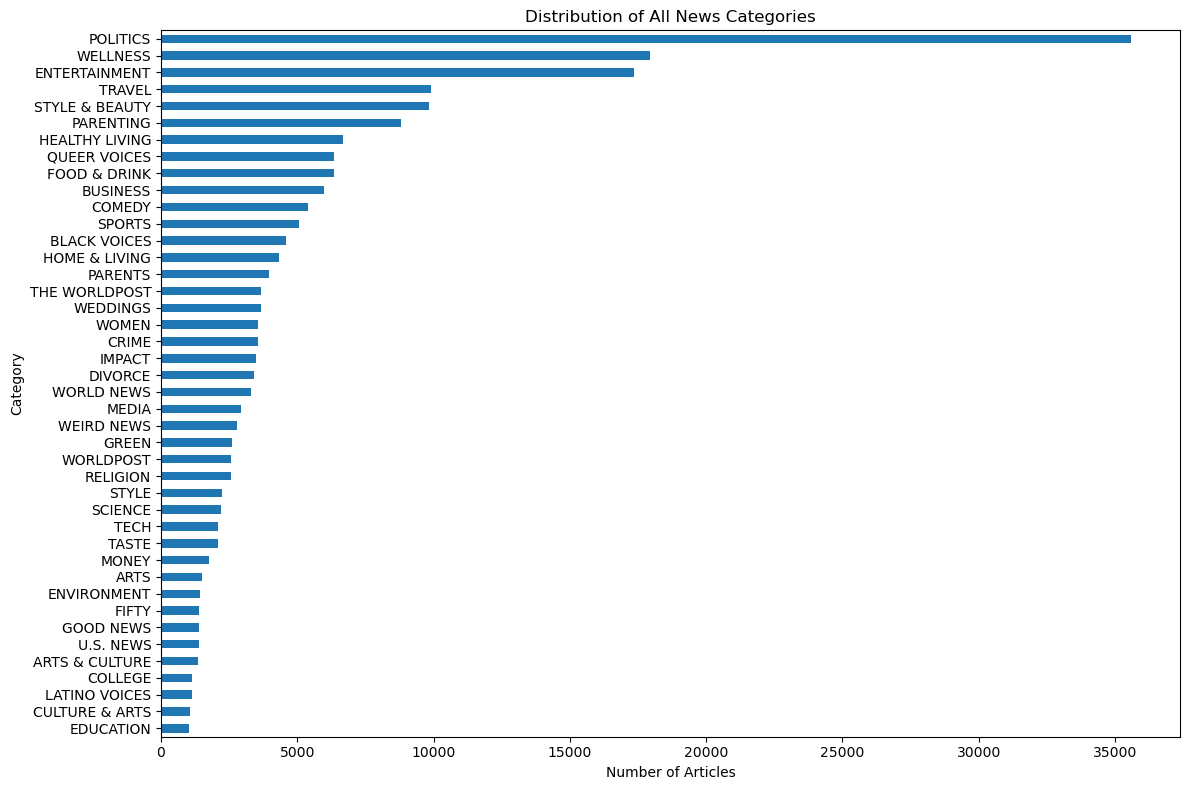

In [8]:
plt.figure(figsize=(12, 8))

category_counts.sort_values().plot(kind="barh")

plt.title("Distribution of All News Categories")
plt.xlabel("Number of Articles")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

# Keep Relevant Columns

In [9]:
df = df[
    [
        "headline",
        "short_description",
        "category"
    ]
].copy()

display(df.head())

,headline,short_description,category
0,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for t...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video","He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23),"""Until you have a dog you don't understand what could be eaten.""",COMEDY
3,The Funniest Tweets From Parents This Week (Sept. 17-23),"""Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with a Carolina Reaper dipped in Ta...",PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Loses Lawsuit Against Ex-Employer,Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video of the Central Park encounter w...,U.S. NEWS


# Filter the Six Selected Categories

In [10]:
selected_categories = [
    "POLITICS",
    "SPORTS",
    "BUSINESS",
    "ENTERTAINMENT",
    "SCIENCE",
    "TRAVEL"
]

df_filtered = df[
    df["category"].isin(selected_categories)
].copy()

print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df_filtered.shape)

display(
    df_filtered["category"]
    .value_counts()
)

Original dataset shape: (209527, 3)
Filtered dataset shape: (76139, 3)


category
POLITICS         35602
ENTERTAINMENT    17362
TRAVEL            9900
BUSINESS          5992
SPORTS            5077
SCIENCE           2206
Name: count, dtype: int64

# Clean Missing and Empty Values

In [11]:
df_filtered["headline"] = (
    df_filtered["headline"]
    .fillna("")
    .astype(str)
)

df_filtered["short_description"] = (
    df_filtered["short_description"]
    .fillna("")
    .astype(str)
)

df_filtered["category"] = (
    df_filtered["category"]
    .fillna("")
    .astype(str)
)

df_filtered = df_filtered[
    (df_filtered["headline"].str.strip() != "") &
    (df_filtered["short_description"].str.strip() != "") &
    (df_filtered["category"].str.strip() != "")
].copy()

print("Dataset after removing missing/empty values:")
print(df_filtered.shape)

Dataset after removing missing/empty values:
(67985, 3)


# Text Cleaning Function

In [12]:
def clean_text(text):

    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove unnecessary whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [13]:
df_filtered["clean_headline"] = (
    df_filtered["headline"]
    .apply(clean_text)
)

df_filtered["clean_description"] = (
    df_filtered["short_description"]
    .apply(clean_text)
)

# Combine Headline and Description

In [14]:
df_filtered["combined_text"] = (
    df_filtered["clean_headline"]
    + ". "
    + df_filtered["clean_description"]
)

display(
    df_filtered[
        [
            "clean_headline",
            "clean_description",
            "combined_text",
            "category"
        ]
    ].head()
)

,clean_headline,clean_description,combined_text,category
17,"Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89","Maury Wills, who helped the Los Angeles Dodgers win three World Series titles with his base-stealing prowess, has died.","Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89. Maury Wills, who helped the Los Angeles Dodgers win three World Series titles with h...",SPORTS
20,Golden Globes Returning To NBC In January After Year Off-Air,"For the past 18 months, Hollywood has effectively boycotted the Globes after reports that the HFPA’s 87 members of non-American journalists includ...","Golden Globes Returning To NBC In January After Year Off-Air. For the past 18 months, Hollywood has effectively boycotted the Globes after reports...",ENTERTAINMENT
21,Biden Says U.S. Forces Would Defend Taiwan If China Invaded,President issues vow as tensions with China rise.,Biden Says U.S. Forces Would Defend Taiwan If China Invaded. President issues vow as tensions with China rise.,POLITICS
24,‘Beautiful And Sad At The Same Time’: Ukrainian Cultural Festival Takes On A Deeper Meaning This Year,An annual celebration took on a different feel as Russia's invasion dragged into Day 206.,‘Beautiful And Sad At The Same Time’: Ukrainian Cultural Festival Takes On A Deeper Meaning This Year. An annual celebration took on a different f...,POLITICS
26,"Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP",Las Vegas never had a professional sports champion — until Sunday.,"Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP. Las Vegas never had a professional sports champion — until Sunday.",SPORTS


# Remove Duplicate Articles

In [15]:
print(
    "Duplicates before removal:",
    df_filtered.duplicated(
        subset=["combined_text", "category"]
    ).sum()
)

df_filtered = df_filtered.drop_duplicates(
    subset=["combined_text", "category"]
).reset_index(drop=True)

print("Final cleaned dataset shape:", df_filtered.shape)

Duplicates before removal: 21
Final cleaned dataset shape: (67964, 6)


# Visualise Final Six-Category Distribution

category
POLITICS         32427
ENTERTAINMENT    14772
TRAVEL            9418
BUSINESS          5130
SPORTS            4414
SCIENCE           1803
Name: count, dtype: int64

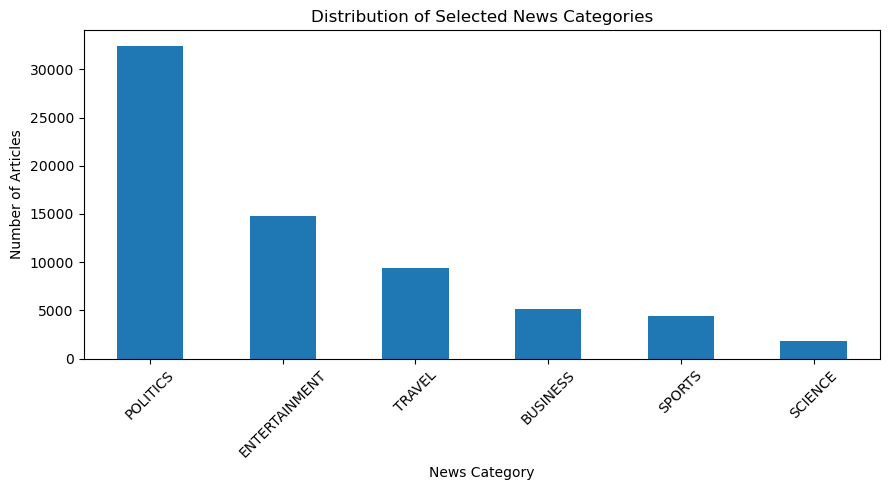

In [16]:
final_counts = (
    df_filtered["category"]
    .value_counts()
    .sort_values(ascending=False)
)

display(final_counts)

plt.figure(figsize=(9, 5))

final_counts.plot(kind="bar")

plt.title("Distribution of Selected News Categories")
plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Export Cleaned Data to CSV

In [17]:
output_columns = [
    "clean_headline",
    "clean_description",
    "combined_text",
    "category"
]

df_filtered[output_columns].to_csv(
    "cleaned_news_category_dataset.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


# Train/Test Split for Main Model

In [18]:
X = df_filtered["combined_text"]
y = df_filtered["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining percentage:")
print(round(len(X_train) / len(X) * 100, 2), "%")

print("\nTesting percentage:")
print(round(len(X_test) / len(X) * 100, 2), "%")

Training samples: 54371
Testing samples: 13593

Training percentage:
80.0 %

Testing percentage:
20.0 %


# TF-IDF Feature Extraction

In [19]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (54371, 50000)
Testing TF-IDF shape: (13593, 50000)


# Train Logistic Regression

In [20]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# Evaluate Main Model

In [21]:
y_pred = logistic_model.predict(
    X_test_tfidf
)

main_accuracy = accuracy_score(
    y_test,
    y_pred
)

main_macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("MAIN MODEL RESULTS")
print("------------------")

print(
    f"Accuracy: {main_accuracy:.4f}"
)

print(
    f"Macro F1 Score: {main_macro_f1:.4f}"
)

MAIN MODEL RESULTS
------------------
Accuracy: 0.8844
Macro F1 Score: 0.8386


In [22]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


Classification Report:

               precision    recall  f1-score   support

     BUSINESS     0.6596    0.8177    0.7302      1026
ENTERTAINMENT     0.8902    0.8923    0.8913      2954
     POLITICS     0.9528    0.8876    0.9190      6485
      SCIENCE     0.6983    0.7950    0.7435       361
       SPORTS     0.8207    0.8811    0.8498       883
       TRAVEL     0.8806    0.9161    0.8980      1884

     accuracy                         0.8844     13593
    macro avg     0.8170    0.8650    0.8386     13593
 weighted avg     0.8917    0.8844    0.8867     13593



# Confusion Matrix: RQ2

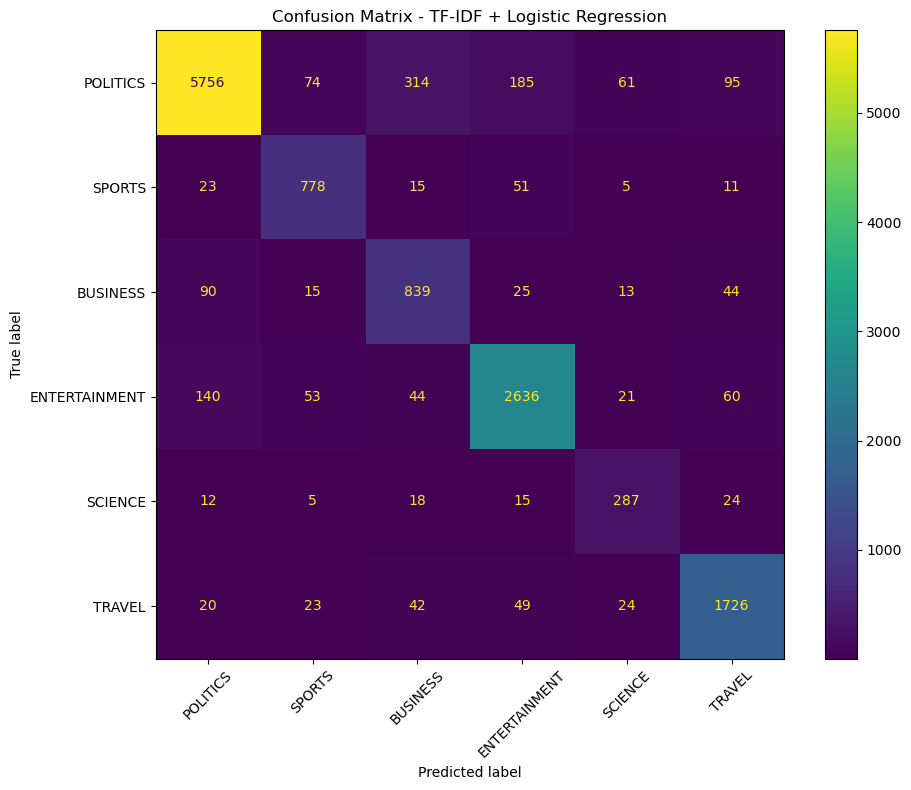

In [23]:
labels = selected_categories

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix - TF-IDF + Logistic Regression"
)

plt.tight_layout()
plt.show()

In [24]:
confusion_records = []

for i, actual in enumerate(labels):

    for j, predicted in enumerate(labels):

        if i != j:

            confusion_records.append(
                {
                    "Actual": actual,
                    "Predicted": predicted,
                    "Count": cm[i, j]
                }
            )

confusion_df = pd.DataFrame(
    confusion_records
).sort_values(
    "Count",
    ascending=False
)

display(confusion_df.head(10))

,Actual,Predicted,Count
1,POLITICS,BUSINESS,314
2,POLITICS,ENTERTAINMENT,185
15,ENTERTAINMENT,POLITICS,140
4,POLITICS,TRAVEL,95
10,BUSINESS,POLITICS,90
0,POLITICS,SPORTS,74
3,POLITICS,SCIENCE,61
19,ENTERTAINMENT,TRAVEL,60
16,ENTERTAINMENT,SPORTS,53
7,SPORTS,ENTERTAINMENT,51


# RQ1: Effect of Number of Categories

In [25]:
category_experiments = {

    "2 Categories": [
        "POLITICS",
        "SPORTS"
    ],

    "4 Categories": [
        "POLITICS",
        "SPORTS",
        "BUSINESS",
        "ENTERTAINMENT"
    ],

    "6 Categories": [
        "POLITICS",
        "SPORTS",
        "BUSINESS",
        "ENTERTAINMENT",
        "SCIENCE",
        "TRAVEL"
    ]
}

In [26]:
rq1_results = []

for experiment_name, categories in category_experiments.items():

    experiment_df = df_filtered[
        df_filtered["category"].isin(categories)
    ]

    X_exp = experiment_df["combined_text"]
    y_exp = experiment_df["category"]

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp,
        y_exp,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_exp
    )

    vectorizer_exp = TfidfVectorizer(
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )

    X_train_vec = vectorizer_exp.fit_transform(
        X_train_exp
    )

    X_test_vec = vectorizer_exp.transform(
        X_test_exp
    )

    model_exp = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )

    model_exp.fit(
        X_train_vec,
        y_train_exp
    )

    pred_exp = model_exp.predict(
        X_test_vec
    )

    accuracy_exp = accuracy_score(
        y_test_exp,
        pred_exp
    )

    macro_f1_exp = f1_score(
        y_test_exp,
        pred_exp,
        average="macro"
    )

    rq1_results.append(
        {
            "Experiment": experiment_name,
            "Number_of_Categories": len(categories),
            "Number_of_Articles": len(experiment_df),
            "Accuracy": accuracy_exp,
            "Macro_F1": macro_f1_exp
        }
    )

rq1_results_df = pd.DataFrame(
    rq1_results
)

display(rq1_results_df)

,Experiment,Number_of_Categories,Number_of_Articles,Accuracy,Macro_F1
0,2 Categories,2,36841,0.976116,0.944992
1,4 Categories,4,56743,0.900784,0.863528
2,6 Categories,6,67964,0.884426,0.838649


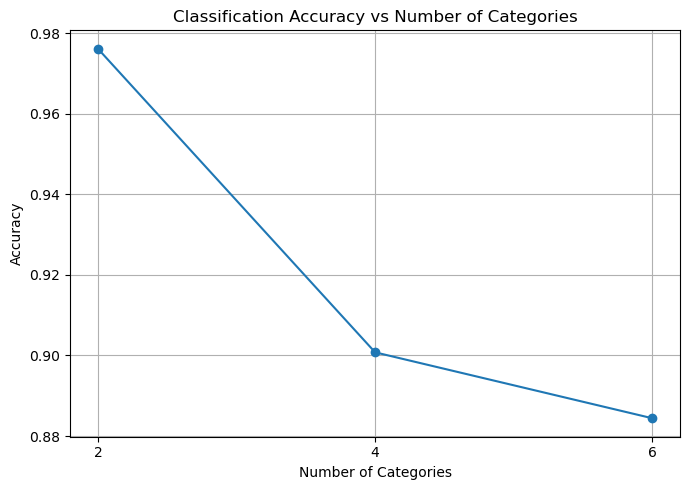

In [27]:
plt.figure(figsize=(7, 5))

plt.plot(
    rq1_results_df["Number_of_Categories"],
    rq1_results_df["Accuracy"],
    marker="o"
)

plt.title(
    "Classification Accuracy vs Number of Categories"
)

plt.xlabel(
    "Number of Categories"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    rq1_results_df["Number_of_Categories"]
)

plt.grid(True)

plt.tight_layout()
plt.show()

# RQ3: Headline vs Headline + Description

In [28]:
def evaluate_text_source(text_column, experiment_name):

    X = df_filtered[text_column]
    y = df_filtered["category"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )

    X_train_vec = vectorizer.fit_transform(
        X_train
    )

    X_test_vec = vectorizer.transform(
        X_test
    )

    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )

    model.fit(
        X_train_vec,
        y_train
    )

    predictions = model.predict(
        X_test_vec
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    return {
        "Input": experiment_name,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    }

In [29]:
headline_result = evaluate_text_source(
    "clean_headline",
    "Headline Only"
)

combined_result = evaluate_text_source(
    "combined_text",
    "Headline + Description"
)

rq3_results = pd.DataFrame(
    [
        headline_result,
        combined_result
    ]
)

display(rq3_results)

,Input,Accuracy,Macro_F1
0,Headline Only,0.851394,0.792280
1,Headline + Description,0.884426,0.838649


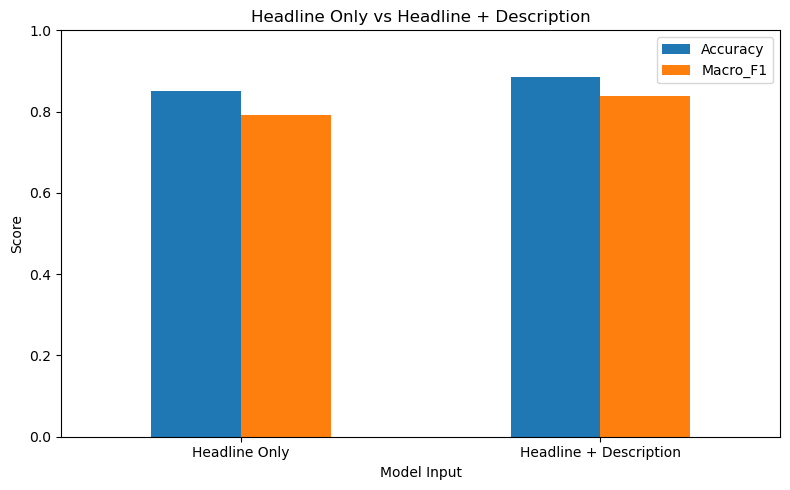

In [30]:
rq3_results.set_index(
    "Input"
)[
    ["Accuracy", "Macro_F1"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Headline Only vs Headline + Description"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model Input"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

# Optional Sentence-BERT Model

In [31]:
from sentence_transformers import SentenceTransformer

In [32]:
sbert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [33]:
SBERT_SAMPLE_SIZE = min(
    30000,
    len(df_filtered)
)

sbert_df = df_filtered.sample(
    n=SBERT_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

X_sbert = sbert_df["combined_text"]
y_sbert = sbert_df["category"]

X_train_sbert, X_test_sbert, y_train_sbert, y_test_sbert = train_test_split(
    X_sbert,
    y_sbert,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sbert
)

print(
    "Generating Sentence-BERT embeddings..."
)

X_train_embeddings = sbert_model.encode(
    X_train_sbert.tolist(),
    show_progress_bar=True,
    batch_size=64
)

X_test_embeddings = sbert_model.encode(
    X_test_sbert.tolist(),
    show_progress_bar=True,
    batch_size=64
)

Generating Sentence-BERT embeddings...


Batches:   0%|          | 0/375 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [34]:
sbert_classifier = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

sbert_classifier.fit(
    X_train_embeddings,
    y_train_sbert
)

sbert_predictions = sbert_classifier.predict(
    X_test_embeddings
)

sbert_accuracy = accuracy_score(
    y_test_sbert,
    sbert_predictions
)

sbert_macro_f1 = f1_score(
    y_test_sbert,
    sbert_predictions,
    average="macro"
)

print(
    "Sentence-BERT Accuracy:",
    round(sbert_accuracy, 4)
)

print(
    "Sentence-BERT Macro F1:",
    round(sbert_macro_f1, 4)
)

Sentence-BERT Accuracy: 0.8752
Sentence-BERT Macro F1: 0.8237


## Final Results Table

In [35]:
final_results = pd.DataFrame(
    {
        "Model": [
            "TF-IDF + Logistic Regression",
            "Sentence-BERT + Logistic Regression"
        ],

        "Accuracy": [
            main_accuracy,
            sbert_accuracy
        ],

        "Macro_F1": [
            main_macro_f1,
            sbert_macro_f1
        ]
    }
)

display(final_results)

,Model,Accuracy,Macro_F1
0,TF-IDF + Logistic Regression,0.884426,0.838649
1,Sentence-BERT + Logistic Regression,0.875167,0.823673


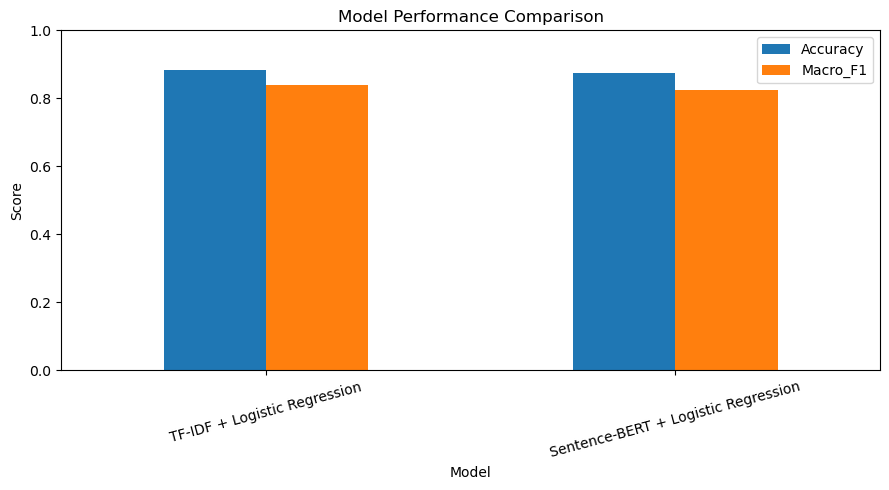

In [36]:
final_results.set_index(
    "Model"
)[
    ["Accuracy", "Macro_F1"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation=15
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()